# Baseline Models

Establishes minimum-acceptable forecasting performance using naive, seasonal-naive, and moving-average forecasts (proposal.txt Section 10.1) on `data/processed/demand_clean.csv`, evaluated on a chronological 70/15/15 train/val/test split (Section 13).

In [ ]:
import os
import sys
from pathlib import Path

import yaml

# Works both in the local repo and on Kaggle. Locally, config.yaml is read
# from disk. On Kaggle there is no repo checkout -- only whatever cells you
# paste -- so the config is built inline instead. This notebook only reads
# from /kaggle/working (produced by 02_data_cleaning.ipynb earlier in the
# same Kaggle session), never from /kaggle/input, so IS_KAGGLE just needs
# KAGGLE_KERNEL_RUN_TYPE (always set on Kaggle) -- no dataset needs to be
# attached for this notebook specifically.
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    REPO_ROOT = Path("/kaggle/working")
    config = {
        "data": {
            "processed_file": "/kaggle/working/data/processed/demand_clean.csv",
            "timestamp_col": "timestamp",
            "target_col": "demand",
            "frequency": "h",
        },
        "split": {"train_ratio": 0.70, "val_ratio": 0.15, "test_ratio": 0.15},
    }
else:
    def find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "config.yaml").exists():
                return parent
        raise FileNotFoundError("config.yaml not found in any parent directory")

    REPO_ROOT = find_repo_root(Path.cwd())
    sys.path.insert(0, str(REPO_ROOT))

    with open(REPO_ROOT / "config.yaml") as f:
        config = yaml.safe_load(f)

config

In [2]:
import numpy as np
import pandas as pd

# On Kaggle, src/ isn't on disk (only pasted cells are) -- these are
# identical inline copies of src/data/load_data.py, src/models/baseline.py,
# src/evaluation/metrics.py, and src/visualization/plots.py.
# Keep them in sync with src/ if that logic ever changes.
if IS_KAGGLE:
    import matplotlib.pyplot as plt

    def load_raw_data(path, timestamp_col="timestamp"):
        df = pd.read_csv(path, parse_dates=[timestamp_col])
        return df.sort_values(timestamp_col).reset_index(drop=True)

    def set_timestamp_index(df, timestamp_col="timestamp"):
        df = df.set_index(timestamp_col)
        return df.sort_index()

    def chronological_split(df, train_ratio, val_ratio):
        n = len(df)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))
        return df.iloc[:train_end], df.iloc[train_end:val_end], df.iloc[val_end:]

    def naive_forecast(series):
        return series.shift(1)

    def seasonal_naive_forecast(series, season_length):
        return series.shift(season_length)

    def moving_average_forecast(series, window):
        return series.shift(1).rolling(window).mean()

    def mae(y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    def mape(y_true, y_pred):
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    def smape(y_true, y_pred):
        denom = (np.abs(y_true) + np.abs(y_pred)) / 2
        return np.mean(np.abs(y_true - y_pred) / denom) * 100

    def mase(y_true, y_pred, y_train, season_length=1):
        naive_error = np.mean(np.abs(y_train[season_length:] - y_train[:-season_length]))
        return np.mean(np.abs(y_true - y_pred)) / naive_error

    def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(y_true.index, y_true.values, label="Actual")
        ax.plot(y_pred.index, y_pred.values, label="Predicted", alpha=0.8)
        ax.set_title(title)
        ax.legend()
        return fig
else:
    from src.data.load_data import chronological_split, load_raw_data, set_timestamp_index
    from src.evaluation.metrics import mae, mape, mase, rmse, smape
    from src.models.baseline import moving_average_forecast, naive_forecast, seasonal_naive_forecast
    from src.visualization.plots import plot_actual_vs_predicted

PROCESSED_PATH = REPO_ROOT / config["data"]["processed_file"]
TIMESTAMP_COL = config["data"]["timestamp_col"]
TARGET_COL = config["data"]["target_col"]
TRAIN_RATIO = config["split"]["train_ratio"]
VAL_RATIO = config["split"]["val_ratio"]

## Load data and chronological split

In [3]:
df = load_raw_data(PROCESSED_PATH, TIMESTAMP_COL)
df = set_timestamp_index(df, TIMESTAMP_COL)

train_df, val_df, test_df = chronological_split(df, TRAIN_RATIO, VAL_RATIO)
print(f"Train: {train_df.index.min()} -> {train_df.index.max()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index.min()} -> {val_df.index.max()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index.min()} -> {test_df.index.max()} ({len(test_df)} rows)")

Train: 2020-01-01 00:00:00 -> 2023-10-16 13:00:00 (33230 rows)
Val:   2023-10-16 14:00:00 -> 2024-08-08 06:00:00 (7121 rows)
Test:  2024-08-08 07:00:00 -> 2025-05-31 23:00:00 (7121 rows)


## Generate baseline forecasts

Each forecast is computed on the full series with `shift`, so a prediction for a test-set timestamp only ever uses past actual values -- never future information.

In [4]:
demand = df[TARGET_COL]

forecasts = {
    "Naive (previous hour)": naive_forecast(demand),
    "Seasonal naive (previous day)": seasonal_naive_forecast(demand, 24),
    "Seasonal naive (previous week)": seasonal_naive_forecast(demand, 24 * 7),
    "Moving average (24h)": moving_average_forecast(demand, 24),
}

## Evaluate on the test set

In [5]:
y_test = test_df[TARGET_COL]
y_train = train_df[TARGET_COL].to_numpy()

results = []
for name, forecast in forecasts.items():
    y_pred = forecast.loc[y_test.index]
    valid = y_test.notna() & y_pred.notna()
    results.append({
        "model": name,
        "mae": mae(y_test[valid], y_pred[valid]),
        "rmse": rmse(y_test[valid], y_pred[valid]),
        "mape": mape(y_test[valid], y_pred[valid]),
        "smape": smape(y_test[valid], y_pred[valid]),
        "mase": mase(y_test[valid].to_numpy(), y_pred[valid].to_numpy(), y_train, season_length=24),
    })

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

,model,mae,rmse,mape,smape,mase
0,Moving average (24h),81.332470,102.459940,5.473647,5.435826,0.717041
1,Seasonal naive (previous week),113.315391,141.643410,7.608635,7.574782,0.999008
2,Seasonal naive (previous day),112.941008,142.237362,7.588907,7.550213,0.995708
3,Naive (previous hour),114.125999,143.161920,7.659646,7.623723,1.006155


## Visualize the best baseline

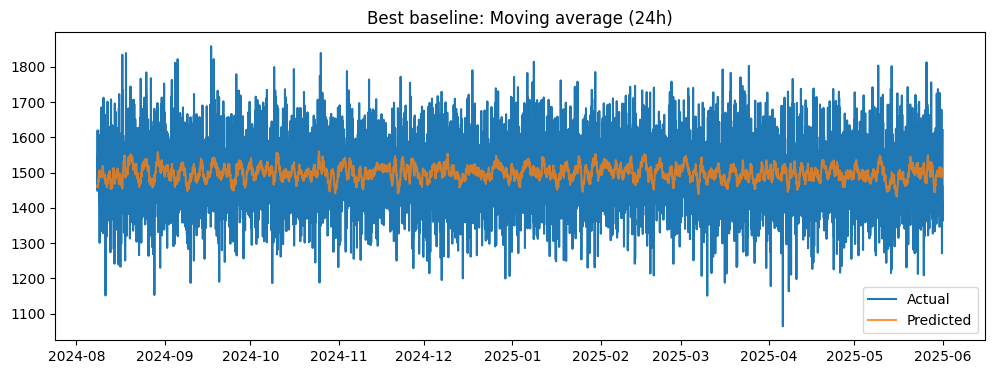

In [6]:
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

best_model = results_df.iloc[0]["model"]
best_forecast = forecasts[best_model].loc[y_test.index]

fig = plot_actual_vs_predicted(y_test, best_forecast, title=f"Best baseline: {best_model}")
fig.savefig(FIGURES_DIR / "baseline_best_forecast.png", dpi=150, bbox_inches="tight")

## Save baseline results

In [7]:
RESULTS_PATH = REPO_ROOT / "reports" / "baseline_metrics.csv"
results_df.to_csv(RESULTS_PATH, index=False)
print(f"Saved baseline results to {RESULTS_PATH}")

Saved baseline results to /kaggle/working/reports/baseline_metrics.csv


## Save predictions for cross-notebook comparison

Used by `10_model_comparison.ipynb` to overlay forecasts and run Diebold-Mariano significance tests across all model families.

In [8]:
predictions_records = []
for name, forecast in forecasts.items():
    y_pred = forecast.loc[y_test.index]
    valid = y_test.notna() & y_pred.notna()
    predictions_records.append(pd.DataFrame({
        "timestamp": y_test.index[valid],
        "actual": y_test[valid].values,
        "predicted": y_pred[valid].values,
        "model": name,
    }))

predictions_df = pd.concat(predictions_records, ignore_index=True)
PREDICTIONS_PATH = REPO_ROOT / "reports" / "baseline_predictions.csv"
predictions_df.to_csv(PREDICTIONS_PATH, index=False)
print(f"Saved {len(predictions_df)} prediction rows to {PREDICTIONS_PATH}")

Saved 28484 prediction rows to /kaggle/working/reports/baseline_predictions.csv
